In [3]:
from sklearn.feature_extraction.text import CountVectorizer

reviews = [
    "The product is fantastic! It works like a charm.",
    "I hated the product. It broke after one use.",
    "Product was okay, not the best, but fine overall."
]

# Preprocess each review
cleaned_reviews = [preprocess(review) for review in reviews]

vectorizer = CountVectorizer()

# Fit the vectorizer
vectorizer.fit(cleaned_reviews)

# Print learned words (FEATURE NAMES)
print(vectorizer.get_feature_names_out())

['after' 'best' 'broke' 'but' 'charm' 'fantastic' 'fine' 'hated' 'is' 'it'
 'like' 'not' 'okay' 'one' 'overall' 'product' 'the' 'use' 'was' 'works']


In [4]:
# Transform the reviews
bow_matrix = vectorizer.transform(cleaned_reviews)

# Print the BoW representation
print(bow_matrix.toarray())

[[0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 1 1 0 0 1]
 [1 0 1 0 0 0 0 1 0 1 0 0 0 1 0 1 1 1 0 0]
 [0 1 0 1 0 0 1 0 0 0 0 1 1 0 1 1 1 0 1 0]]


In [13]:
from nltk.tokenize import word_tokenize
import string
from nltk.corpus import stopwords
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

stop_words = set(stopwords.words('english'))

def get_top_ten(words, word_counts):
    # sort indices by frequency (descending)
    sorted_idx = word_counts.argsort()[::-1][:10]
    
    top_words = words[sorted_idx]
    top_counts = word_counts[sorted_idx]
    
    return top_words, top_counts


def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    
    # remove punctuation and stopwords
    tokens = [word for word in tokens 
              if word not in string.punctuation 
              and word not in stop_words]
    
    return " ".join(tokens)


# -----------------------------
# WITH STOPWORDS (original reviews)
# -----------------------------
vectorizer_with = CountVectorizer()
cleaned_reviews = [preprocess(review) for review in reviews]

X = vectorizer_with.fit_transform(cleaned_reviews)

word_counts = np.sum(X.toarray(), axis=0)
words = vectorizer_with.get_feature_names_out()

top_words_with_stopwords, top_counts_with_stopwords = get_top_ten(words, word_counts)

print("WITH stopwords:")
print(top_words_with_stopwords, top_counts_with_stopwords)


# -----------------------------
# WITHOUT STOPWORDS (same preprocess already removes stopwords)
# (so this is effectively same, but kept for assignment structure)
# -----------------------------
vectorizer_without = CountVectorizer()

cleaned_reviews_no_stop = [preprocess(review) for review in reviews]

X_no_stop = vectorizer_without.fit_transform(cleaned_reviews_no_stop)

word_counts_no_stop = np.sum(X_no_stop.toarray(), axis=0)
words_no_stop = vectorizer_without.get_feature_names_out()

top_words_without_stopwords, top_counts_without_stopwords = get_top_ten(
    words_no_stop, word_counts_no_stop
)

print("\nWITHOUT stopwords:")
print(top_words_without_stopwords, top_counts_without_stopwords)

WITH stopwords:
['product' 'works' 'use' 'overall' 'one' 'okay' 'like' 'hated' 'fine'
 'fantastic'] [3 1 1 1 1 1 1 1 1 1]

WITHOUT stopwords:
['product' 'works' 'use' 'overall' 'one' 'okay' 'like' 'hated' 'fine'
 'fantastic'] [3 1 1 1 1 1 1 1 1 1]


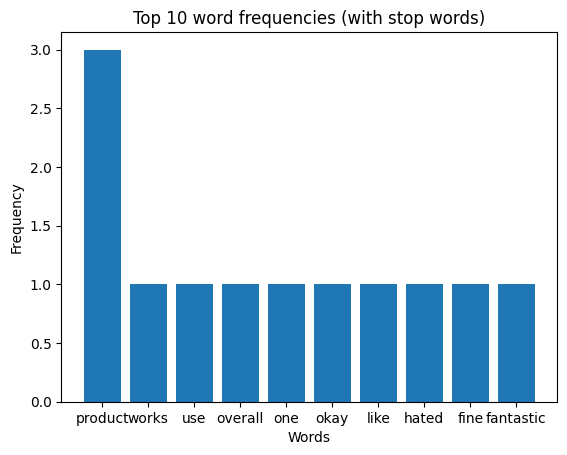

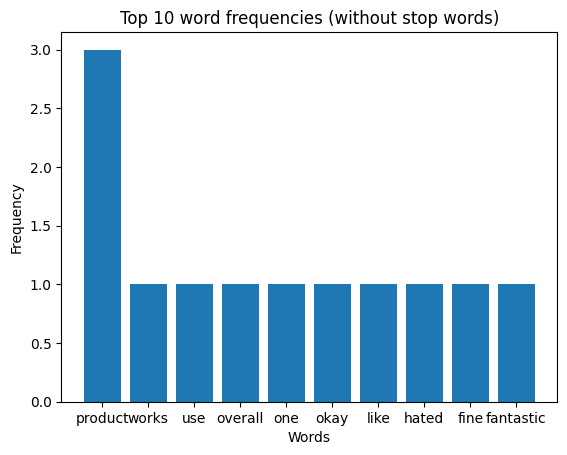

In [14]:
import matplotlib.pyplot as plt

# Plot the frequencies with stop words
plt.bar(top_words_with_stopwords, top_counts_with_stopwords)
plt.title("Top 10 word frequencies (with stop words)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

# Plot the frequencies without stop words
plt.figure()
plt.bar(top_words_without_stopwords, top_counts_without_stopwords)
plt.title("Top 10 word frequencies (without stop words)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()